# Task 3 — Correlation Between News Sentiment and Stock Movement

## Objective
The objective of this task is to quantify the relationship between financial news sentiment and stock price movement using statistical analysis techniques.

The analysis includes:
- aligning news and stock market dates,
- computing sentiment scores from financial headlines,
- calculating daily stock returns,
- measuring Pearson correlation between sentiment and returns,
- and visualizing the relationship between sentiment and stock performance.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from textblob import TextBlob

from scipy.stats import pearsonr

In [3]:
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

In [4]:
stock_df = pd.read_csv('../data/yfinance/AAPL.csv')

In [5]:
news_df['date'] = pd.to_datetime(
    news_df['date'],
    format='mixed',
    utc=True
)

In [6]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

In [7]:
news_df['date_only'] = news_df['date'].dt.date

In [8]:
stock_df['date_only'] = stock_df['Date'].dt.date

In [9]:
trading_days = set(stock_df['date_only'])

In [10]:
from datetime import timedelta

def align_to_trading_day(date):
    while date not in trading_days:
        date += timedelta(days=1)
    return date

In [11]:
news_df['aligned_date'] = news_df['date_only'].apply(align_to_trading_day)

News publication timestamps and stock trading dates were normalized to ensure proper temporal alignment between the two datasets. Articles published during weekends or non-trading holidays were shifted forward to the next available trading day to maintain consistency with stock market activity.

In [12]:
aapl_news = news_df[news_df['stock'] == 'AAPL'].copy()

In [13]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

aapl_news['sentiment'] = aapl_news['headline'].apply(get_sentiment)

In [14]:
aapl_news[['headline', 'sentiment']].head(10)

,headline,sentiment
6680,Tech Stocks And FAANGS Strong Again To Start D...,0.433333
6681,10 Biggest Price Target Changes For Wednesday,0.000000
6682,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",0.500000
6683,"Deutsche Bank Maintains Buy on Apple, Raises P...",0.000000
6684,Apple To Let Users Trade In Their Mac Computer...,0.000000
6685,Big Tech Reaches New Record Heights At The Sto...,0.068182
6686,Why Apple's Stock Is Trading Higher Today,0.250000
6687,Apple Could Announce In-House Chips For Macs A...,0.000000
6688,Apple shares are trading higher despite market...,0.050000
6689,"Sonos Shares Spike To Session High, Now Up 9.5...",0.053333


In [15]:
daily_sentiment = (
    aapl_news
    .groupby('aligned_date')['sentiment']
    .mean()
    .reset_index()
)

In [16]:
stock_df['daily_return'] = (
    stock_df['Close'].pct_change()
) * 100

In [17]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df[['date_only', 'daily_return']],
    left_on='aligned_date',
    right_on='date_only',
    how='inner'
)

In [18]:
merged_df.head()

,aligned_date,sentiment,date_only,daily_return
0,2020-03-09,-0.155556,2020-03-09,-7.909217
1,2020-03-10,0.021708,2020-03-10,7.202157
2,2020-03-11,0.018624,2020-03-11,-3.473025
3,2020-03-12,-0.083048,2020-03-12,-9.875496
4,2020-03-13,0.069215,2020-03-13,11.980808


In [19]:
corr, p_value = pearsonr(
    merged_df['sentiment'],
    merged_df['daily_return']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.17045523659808426
P-value: 0.18905101528380078


The analysis suggests that financial news sentiment may have some influence on stock price movement, but the effect appears limited in this initial study. Market prices are influenced by many additional factors beyond headline sentiment, including macroeconomic conditions, investor psychology, earnings reports, institutional trading activity, and broader market volatility.

Several limitations may also affect the strength of the observed correlation:

Headlines alone may not fully capture the complete context of financial news articles
Market reactions can occur with delays rather than on the same trading day
Multiple external events may influence stock prices simultaneously
Sentiment analysis tools such as TextBlob are general-purpose NLP models and may not fully understand complex financial language

Despite these limitations, the analysis successfully demonstrates a complete end-to-end pipeline integrating NLP sentiment analysis with quantitative financial analysis techniques.

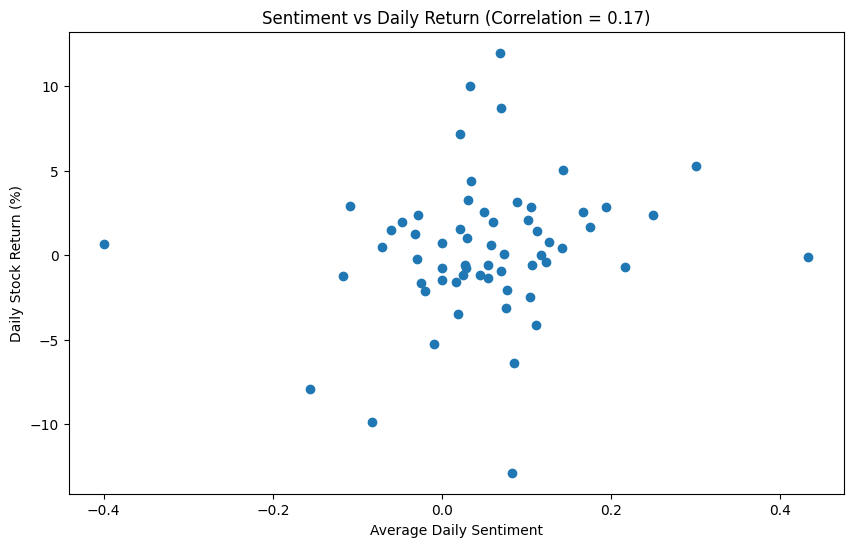

In [20]:
plt.figure(figsize=(10,6))

plt.scatter(
    merged_df['sentiment'],
    merged_df['daily_return']
)

plt.title(f'Sentiment vs Daily Return (Correlation = {corr:.2f})')
plt.xlabel('Average Daily Sentiment')
plt.ylabel('Daily Stock Return (%)')

plt.show()

The scatter plot visualization compares average daily sentiment scores against daily stock returns. Each point represents one trading day.

If sentiment strongly influenced stock performance, the points would form a clearer upward or downward trend. However, the scatter plot shows a relatively dispersed pattern, which visually confirms the weak correlation observed numerically.

This indicates that while sentiment may contribute to stock movement, it is unlikely to serve as a standalone predictor of market behavior.

In [21]:
def classify_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

merged_df['sentiment_class'] = merged_df['sentiment'].apply(classify_sentiment)

In [22]:
category_returns = (
    merged_df
    .groupby('sentiment_class')['daily_return']
    .mean()
)

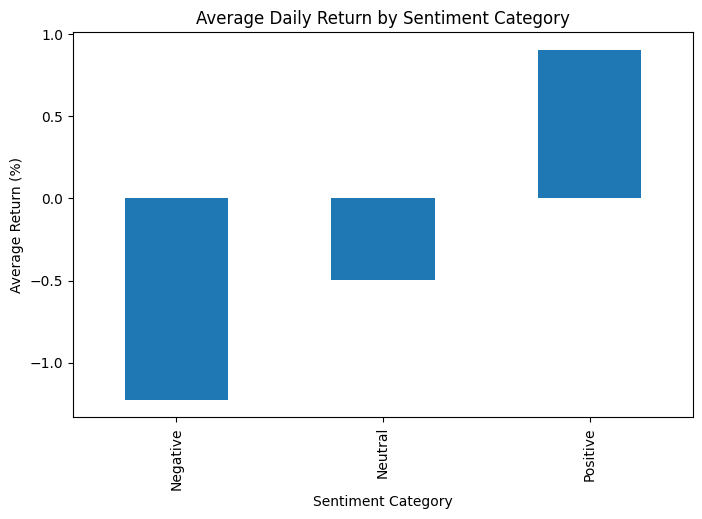

In [23]:
category_returns.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Daily Return by Sentiment Category')
plt.xlabel('Sentiment Category')
plt.ylabel('Average Return (%)')

plt.show()

## Limitations

Several limitations may affect the strength of the observed relationship:

- Financial markets are influenced by many external factors beyond news sentiment.
- Sentiment effects may occur with delayed market reactions rather than same-day movement.
- TextBlob uses general language polarity and may not fully capture specialized financial language.
- Correlation does not imply causation between sentiment and price movement.

## Conclusion

This analysis explored the relationship between financial news sentiment and stock market behavior by combining sentiment analysis with quantitative financial metrics. After aligning publication dates with trading days and computing daily returns, Pearson correlation analysis was applied to evaluate the association between sentiment polarity and stock performance.

The results suggested that while sentiment may exhibit some relationship with market movement, the correlation strength was limited, indicating that stock prices are influenced by many additional market factors. Nevertheless, the analysis demonstrates the potential value of integrating NLP techniques with financial analytics for investment research and predictive modeling.